# 12 — Đánh giá TEST cuối cùng + Giải thích mô hình (SHAP) + Report

**Bước 6 — bước cuối của quy trình.** Đến đây ta MỚI mở tập **TEST** (dữ liệu tương lai chưa từng đụng), refit model trên **Train+Val** với `BEST_PARAMS` + `CHOSEN_THRESHOLD` (từ nb11) → báo cáo **một lần**.

**Ba việc:**
1. **Đánh giá test cuối** — PR-AUC + confusion matrix + precision@k tại ngưỡng đã chốt.
2. **SHAP** — giải thích model bắt fraud dựa trên feature nào; đối chiếu 3 nguồn importance (SHAP vs gain vs permutation) xem có đồng thuận không.
3. **Report trung thực** — model dùng gì, PR-AUC ở mức này *vì sao*, giới hạn.

> **Exploratory / non-promotable.** Test ở đây để *học đánh giá đúng cách*, không phải gate promote. Bản chốt chạy `training/` + manifest. Tag MLflow `manifest_backed=false`.

⚠️ **Kỷ luật:** không quay lại sửa feature/param sau khi nhìn test. Nhìn test rồi chỉnh = rò rỉ. Nếu test tệ hơn val nhiều → đó là *kết quả*, ghi vào report, không giấu.

📖 **Cell dưới — Setup** (y hệt nb10/11) + `DEPLOYABLE_CORE`. In `READY`.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

from pit_fintech.models.notebook_lab import DEPLOYABLE_CORE, PIT12, resolve_lab_paths

paths = resolve_lab_paths()
READY = paths.ready
print(paths.as_dict())

{'paysim_csv': True, 'silver_transactions': True, 'labels': True, 'ready': True}


## Execution control

📖 **Cell dưới — Bàn giao từ nb11.** Dán `BEST_PARAMS` và `CHOSEN_THRESHOLD` in ra ở notebook 11 vào đây.

> Mặc định để sẵn **config đã validate ở nb10** để notebook chạy được ngay cả khi bạn chưa chạy nb11. Chạy nb11 xong thì thay bằng số thật để phản ánh tuning.

In [2]:
RUN_FINAL = True
SEED = 20_260_727
from pit_fintech.models.notebook_lab import load_selected_features

FEATURES = load_selected_features(
    DEPLOYABLE_CORE
)  # bo feature chot o nb09 (fallback DEPLOYABLE_CORE neu chua chay nb09)
print(f"FEATURES ({len(FEATURES)}) = {FEATURES}")

# <-- DAN tu notebook 11 (BEST_PARAMS + CHOSEN_THRESHOLD in o cuoi nb11).
# Mac dinh = config da validate o nb10 de notebook chay duoc ngay ca khi chua chay nb11.
BEST_PARAMS = dict(
    scale_pos_weight=1.3822600069107835,
    learning_rate=0.025357178098216093,
    num_leaves=63,
    max_depth=6,
    min_child_samples=98,
    subsample=0.9253790248002398,
    colsample_bytree=0.8077368104775222,
    reg_lambda=0.02186874530967611,
)
CHOSEN_THRESHOLD = 0.090128  # None -> tu chon lai tren VAL tai FPR=1%; hoac dan so tu nb11

LOG_TO_MLFLOW = True
print(f"BEST_PARAMS = {BEST_PARAMS}")

FEATURES (6) = ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_amount_168h', 'pit_distinct_senders_168h']
BEST_PARAMS = {'scale_pos_weight': 1.3822600069107835, 'learning_rate': 0.025357178098216093, 'num_leaves': 63, 'max_depth': 6, 'min_child_samples': 98, 'subsample': 0.9253790248002398, 'colsample_bytree': 0.8077368104775222, 'reg_lambda': 0.02186874530967611}


📖 **Cell dưới — Nạp `frame` + 3 split.** Ngưỡng chọn out-of-sample (model train-only chấm trên Val) nếu `CHOSEN_THRESHOLD=None`, rồi **refit `final_model` trên Train+Val** (dùng hết dữ liệu phát triển) với `BEST_PARAMS`. Test (`>631`) chỉ mở ở Phần A bên dưới.

In [3]:
final_model = splits = None
if RUN_FINAL and READY:
    import lightgbm as lgb
    import pandas as pd
    from sklearn.metrics import roc_curve

    from pit_fintech.models.notebook_lab import load_modeling_frame, three_way_temporal_split

    frame = load_modeling_frame(paths)
    splits = three_way_temporal_split(frame)
    train_df, val_df = splits["train"], splits["val"]
    dev_df = pd.concat([train_df, val_df])  # development data = Train+Val (step <= 631)

    def _fit(data):
        pos = int((data["isFraud"] == 1).sum())
        neg = int((data["isFraud"] == 0).sum())
        spw = float(np.sqrt(neg / max(pos, 1)))
        # spw (heuristic sqrt) la default; neu BEST_PARAMS co scale_pos_weight (da tune o nb11)
        # thi no override. Gop truoc de tranh truyen trung keyword 'scale_pos_weight'.
        model = lgb.LGBMClassifier(
            objective="binary",
            subsample_freq=1,
            deterministic=True,
            force_row_wise=True,
            seed=SEED,
            n_jobs=-1,
            verbose=-1,
            **{"scale_pos_weight": spw, **BEST_PARAMS},
        )
        model.fit(data[FEATURES], data["isFraud"])
        return model

    # Nguong chon OUT-OF-SAMPLE: model train-only cham tren Val. Nho vay khi gop Val vao fit cuoi,
    # diem van hanh khong bao gio in-sample. Neu nb11 da cho CHOSEN_THRESHOLD thi giu nguyen.
    if CHOSEN_THRESHOLD is None:
        thr_model = _fit(train_df)
        pv = thr_model.predict_proba(val_df[FEATURES])[:, 1]
        fpr, tpr, thr = roc_curve(val_df["isFraud"], pv)
        CHOSEN_THRESHOLD = float(thr[int(np.max(np.where(fpr <= 0.01)))])

    # Model CUOI = refit tren toan bo du lieu phat trien (Train+Val) -> danh gia MOT lan tren Test.
    final_model = _fit(dev_df)
    print(
        f"final refit on Train+Val ({len(dev_df):,} rows) | CHOSEN_THRESHOLD={CHOSEN_THRESHOLD:.6f}"
    )
else:
    print("Skipped: set RUN_FINAL = True (va data READY).")

final refit on Train+Val (2,732,430 rows) | CHOSEN_THRESHOLD=0.090128


## Phần A · Đánh giá TEST — một lần duy nhất

📖 **Cell dưới — Toàn bộ metric trên TEST:** PR-AUC/ROC-AUC/log_loss/Brier (không ngưỡng) + confusion matrix & P/R/F1 tại `CHOSEN_THRESHOLD` + precision@k/recall@k theo ngân sách review.

In [4]:
test_report = None
if final_model is not None:
    from sklearn.metrics import (
        average_precision_score,
        brier_score_loss,
        confusion_matrix,
        log_loss,
        roc_auc_score,
    )

    yte = splits["test"]["isFraud"].to_numpy()
    pte = final_model.predict_proba(splits["test"][FEATURES])[:, 1]

    free = {
        "pr_auc": round(float(average_precision_score(yte, pte)), 6),
        "roc_auc": round(float(roc_auc_score(yte, pte)), 6),
        "log_loss": round(float(log_loss(yte, pte, labels=[0, 1])), 6),
        "brier": round(float(brier_score_loss(yte, pte)), 6),
        "prevalence": round(float(yte.mean()), 6),
    }
    yhat = (pte >= CHOSEN_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, yhat, labels=[0, 1]).ravel()
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    at_thr = {
        "threshold": round(CHOSEN_THRESHOLD, 6),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "precision": round(prec, 6),
        "recall": round(rec, 6),
        "f1": round(2 * prec * rec / max(prec + rec, 1e-12), 6),
    }

    budget = []
    total_fraud = int(yte.sum())
    order = np.argsort(-pte)
    for kf in (0.001, 0.005, 0.01):
        k = max(1, int(len(pte) * kf))
        hit = int(yte[order[:k]].sum())
        budget.append(
            {
                "k_frac": kf,
                "k": k,
                "precision_at_k": round(hit / k, 6),
                "recall_at_k": round(hit / max(total_fraud, 1), 6),
            }
        )

    test_report = {"free": free, "at_threshold": at_thr, "budget": budget}
    print("== KHÔNG ngưỡng ==")
    display(pd.DataFrame([free]))
    print("== TẠI CHOSEN_THRESHOLD ==")
    display(pd.DataFrame([at_thr]))
    print("== Ngân sách review ==")
    display(pd.DataFrame(budget))
else:
    print("Skipped: enable RUN_FINAL above.")

== KHÔNG ngưỡng ==


,pr_auc,roc_auc,log_loss,brier,prevalence
0,0.365767,0.823101,0.117082,0.025501,0.032966


== TẠI CHOSEN_THRESHOLD ==


,threshold,TP,FP,FN,TN,precision,recall,f1
0,0.090128,365,388,887,36339,0.484728,0.291534,0.36409


== Ngân sách review ==


,k_frac,k,precision_at_k,recall_at_k
0,0.001,37,1.000000,0.029553
1,0.005,189,1.000000,0.150958
2,0.010,379,0.746702,0.226038


📖 **Cách đọc.** So `pr_auc` với `prevalence` (sàn ngẫu nhiên). `FP` = số khách sạch bị chặn nhầm trên test — nhân chi phí xử lý để thấy tác động. `recall_at_k` = nếu đội chỉ soi top-k%, bắt được bao nhiêu % fraud. Nếu số test *thấp hơn* val → ghi nhận là generalization gap, không quay lại tune.

## Phần B · SHAP — model bắt fraud dựa vào feature nào?

📖 **SHAP là gì (1 câu).** Mỗi dự đoán, SHAP chia *đóng góp* của từng feature vào việc đẩy điểm lên (nghi fraud) hay xuống (nghi sạch), theo lý thuyết trò chơi (Shapley value) — cộng lại đúng bằng dự đoán. Ưu điểm so với `feature_importances_`: cho biết **hướng** (feature cao → fraud tăng hay giảm) chứ không chỉ "quan trọng".

> **Không cần cài `shap`.** LightGBM tự tính TreeSHAP chính xác qua `pred_contrib=True`. Thư viện `shap` xung đột với `numpy 2.4` (kéo `numba` cũ không build được), nên ta dùng SHAP **native của LightGBM** — kết quả y hệt, zero dependency.

📖 **Cell dưới — SHAP values bằng LightGBM native (TreeSHAP).** Lấy mẫu tối đa 5000 dòng test. Ra ma trận `sv` (n×feature) trong không gian **log-odds** (dương = đẩy về fraud).

In [5]:
sv = X_shap = None
if final_model is not None:
    rng = np.random.default_rng(SEED)
    Xtest = splits["test"][FEATURES]
    idx = np.sort(rng.choice(len(Xtest), size=min(5000, len(Xtest)), replace=False))
    X_shap = Xtest.iloc[idx].reset_index(drop=True)
    # TreeSHAP native cua LightGBM -> KHONG can thu vien shap/numba.
    # pred_contrib tra (n, n_features+1); cot cuoi = base value (log-odds).
    contrib = np.asarray(final_model.booster_.predict(X_shap, pred_contrib=True))
    sv = contrib[:, :-1]
    base_value = float(contrib[0, -1])
    print(f"SHAP (LightGBM native TreeSHAP) shape = {sv.shape} | base(log-odds)={base_value:.4f}")
else:
    print("Skipped: enable RUN_FINAL above.")

SHAP (LightGBM native TreeSHAP) shape = (5000, 6) | base(log-odds)=-6.8576


📖 **Cell dưới — Bar + beeswarm.** *Bar*: trung bình |SHAP| = mức quan trọng tổng thể. *Beeswarm*: mỗi điểm 1 giao dịch, trục x = tác động SHAP (log-odds), màu = giá trị feature (đỏ cao/xanh thấp). Dùng thư viện `shap` nếu bạn tình cờ có; không thì **tự vẽ bằng matplotlib** (không cần cài gì).

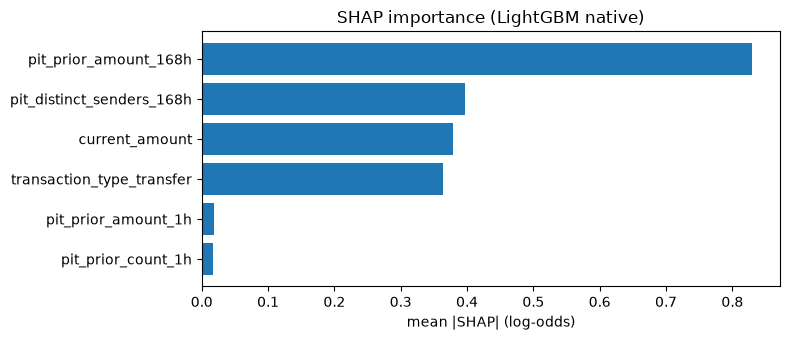

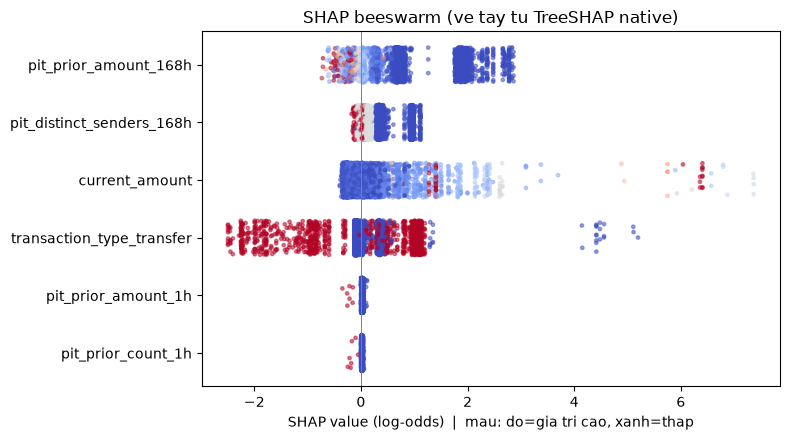

In [6]:
if sv is not None:
    try:
        import matplotlib.pyplot as plt

        rng = np.random.default_rng(SEED)
        mean_abs = np.abs(sv).mean(0)
        order = np.argsort(mean_abs)  # tang dan -> ve tu duoi len
        feats = [FEATURES[i] for i in order]

        # --- Bar: mean|SHAP| ---
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.barh(range(len(feats)), mean_abs[order])
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats)
        ax.set_xlabel("mean |SHAP| (log-odds)")
        ax.set_title("SHAP importance (LightGBM native)")
        fig.tight_layout()
        plt.show()

        # --- Beeswarm: thu vien shap neu co, khong thi ve tay ---
        try:
            import shap

            shap.summary_plot(sv, X_shap, feature_names=FEATURES, show=False, plot_size=(8, 4.5))
            plt.title("SHAP beeswarm (test)")
            plt.tight_layout()
            plt.show()
        except Exception:
            fig, ax = plt.subplots(figsize=(8, 4.5))
            for yi, i in enumerate(order):
                vals = sv[:, i]
                col = X_shap.iloc[:, i].to_numpy(dtype=float)
                lo, hi = np.nanpercentile(col, [1, 99])
                cn = np.clip((col - lo) / (hi - lo + 1e-12), 0, 1)
                jit = yi + (rng.random(len(vals)) - 0.5) * 0.6
                ax.scatter(vals, jit, c=cn, cmap="coolwarm", s=6, alpha=0.5)
            ax.set_yticks(range(len(feats)))
            ax.set_yticklabels(feats)
            ax.axvline(0, color="grey", lw=0.7)
            ax.set_xlabel("SHAP value (log-odds)  |  mau: do=gia tri cao, xanh=thap")
            ax.set_title("SHAP beeswarm (ve tay tu TreeSHAP native)")
            fig.tight_layout()
            plt.show()
    except ImportError:
        print("matplotlib unavailable; xem bang importance o cell duoi.")
else:
    print("Skipped: SHAP values unavailable.")

📖 **Cách đọc beeswarm.** Feature xếp trên cùng = ảnh hưởng mạnh nhất. Với một feature: điểm đỏ (giá trị cao) nằm bên phải nghĩa là *giá trị cao → đẩy về phía fraud*. Ví dụ nếu `current_amount` đỏ dồn bên phải → giao dịch tiền lớn làm model nghi fraud hơn — khớp trực giác nghiệp vụ, và là bằng chứng model học *đúng thứ có nghĩa* (không phải cột rác).

📖 **Cell dưới — Đối chiếu 3 nguồn importance:** SHAP (mean |SHAP|) vs LightGBM **gain** vs **permutation** (đo bằng sụt PR-AUC trên val khi xáo trộn 1 feature). *3 nguồn cùng chỉ vào một feature = tin được* — đúng tinh thần plan Sprint 3.

In [7]:
cmp_imp = None
if final_model is not None:
    from sklearn.inspection import permutation_importance

    gain = final_model.booster_.feature_importance(importance_type="gain")
    perm = permutation_importance(
        final_model,
        splits["test"][FEATURES],
        splits["test"]["isFraud"],
        scoring="average_precision",
        n_repeats=5,
        random_state=SEED,
        n_jobs=-1,
    ).importances_mean
    shap_imp = np.abs(sv).mean(0) if sv is not None else np.full(len(FEATURES), np.nan)

    def rank(x):
        order = np.argsort(-np.asarray(x))
        r = np.empty(len(x), dtype=int)
        r[order] = np.arange(1, len(x) + 1)
        return r

    cmp_imp = (
        pd.DataFrame(
            {
                "feature": FEATURES,
                "shap_mean_abs": np.round(shap_imp, 6),
                "shap_rank": rank(np.nan_to_num(shap_imp)),
                "lgbm_gain": np.round(gain, 2),
                "gain_rank": rank(gain),
                "perm_dropPRAUC": np.round(perm, 6),
                "perm_rank": rank(perm),
            }
        )
        .sort_values("gain_rank")
        .reset_index(drop=True)
    )
    display(cmp_imp)
else:
    print("Skipped: enable RUN_FINAL above.")

,feature,shap_mean_abs,shap_rank,lgbm_gain,gain_rank,perm_dropPRAUC,perm_rank
0,transaction_type_transfer,0.363176,4,582141.82,1,0.193271,2
1,current_amount,0.378266,3,245618.48,2,0.311811,1
2,pit_prior_amount_168h,0.830342,1,183028.89,3,0.024393,3
3,pit_distinct_senders_168h,0.396236,2,86289.91,4,0.012706,4
4,pit_prior_amount_1h,0.018854,5,3283.17,5,-0.000904,6
5,pit_prior_count_1h,0.017054,6,2031.34,6,-0.000227,5


📖 **Cách đọc bảng đối chiếu.** Nhìn 3 cột `*_rank`: feature nào top ở **cả ba** → chắc chắn là feature tải tín hiệu thật. Feature nào rank thấp ở cả ba (đặc biệt `perm_dropPRAUC ≈ 0` = xáo trộn không làm sụt điểm) → ứng viên **redundant/bỏ được** — nối thẳng với ablation nb09. Nếu 3 nguồn *bất đồng* mạnh → cẩn thận, cần điều tra thêm (thường do collinearity giữa các window lồng nhau).

📖 **Cell dưới — Log lên MLflow.** Một run `nb12-final-eval`: params (BEST_PARAMS, threshold, features) + test metrics + bảng importance (artifact). Tag `manifest_backed=false`.

In [8]:
if final_model is not None and LOG_TO_MLFLOW and test_report is not None:
    from pit_fintech.models.notebook_lab import MLFLOW_LAB_TAGS, configure_lab_mlflow

    mlflow = configure_lab_mlflow()
    if mlflow is None:
        print("mlflow not in kernel -> skipped.")
    else:
        with mlflow.start_run(run_name="nb12-final-eval"):
            mlflow.log_params(
                {
                    "features": ",".join(FEATURES),
                    "n_features": len(FEATURES),
                    "threshold": round(CHOSEN_THRESHOLD, 6),
                    "seed": SEED,
                    **{f"hp_{k}": v for k, v in BEST_PARAMS.items()},
                }
            )
            for k, v in test_report["free"].items():
                mlflow.log_metric(f"test_{k}", v)
            for k, v in test_report["at_threshold"].items():
                if k != "threshold":
                    mlflow.log_metric(f"test_{k}", v)
            for b in test_report["budget"]:
                tag = f"{int(b['k_frac'] * 1000)}permil"
                mlflow.log_metric(f"precision_at_{tag}", b["precision_at_k"])
                mlflow.log_metric(f"recall_at_{tag}", b["recall_at_k"])
            if cmp_imp is not None:
                p = "importance_compare.csv"
                cmp_imp.to_csv(p, index=False)
                mlflow.log_artifact(p)
            mlflow.set_tags(
                {
                    **MLFLOW_LAB_TAGS,
                    "stage": "shap",
                    "notebook": "12_shap_final_evaluation",
                    "model": "LightGBM-tuned",
                }
            )
        print("Logged -> nb12-final-eval @", mlflow.get_tracking_uri())
else:
    print("MLflow off hoac chua co test_report.")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🏃 View run nb12-final-eval at: http://100.116.36.6:5000/#/experiments/1/runs/b6e80c7f23eb48269b5102d3d37dbf90
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
Logged -> nb12-final-eval @ http://100.116.36.6:5000


## Report

*(Điền từ output các cell trên. Notebook exploratory / non-promotable — số ở đây để học đánh giá đúng, không phải gate promote.)*

**1. Model học gì?** Đồng thuận top-4 ở cả ba nguồn: `current_amount`, `transaction_type_transfer`, `pit_prior_amount_168h`, `pit_distinct_senders_168h`.
- Hướng (SHAP): tiền lớn + TRANSFER + lịch sử 168h cao → đẩy về fraud — khớp trực giác nghiệp vụ.

**2. PR-AUC** = `0.3658` (prevalence `0.0330`)

- **Ranking:** tại top 0.5% risk (k=189) **precision=1.00, recall=0.151, 0 false positive**; top 0.1% (k=37)
- **Operating point** tại threshold 0.090128: TP=365, FP=388, FN=887, TN=36339 → precision 0.485 / recall 0.292 / F1 0.364. FN (887) > TP (365)

**3. Feature nào redundant?** `pit_prior_amount_1h` và `pit_prior_count_1h` — cả hai là window **1h**. Bottom ở cả 3 nguồn, `perm_dropPRAUC` **âm** (−0.0009 và −0.0002) → xáo trộn còn làm PR-AUC nhỉnh lên = nhiễu thuần. **Tín hiệu lịch sử nằm ở window 168h, không phải 1h.** Nối thẳng với ablation nb09. *Chưa bỏ thật* — bỏ stored feature cần ADR + bump version + backfill (ngoài phạm vi notebook).

In [9]:
from pit_fintech.config import get_settings

print(get_settings().mlflow_tracking_uri)

http://100.116.36.6:5000
